In [ ]:
import pandas as pd


df = pd.read_csv("/X_model.csv")


print(df.columns.tolist())
print(df.head())

['activity_id', 'activity_period_missing', 'scrap_rate (%)', 'recruit_period_days', 'views_log1p', 'scrap_count_log1p', 'recruit_end_dow', 'recruit_end_month', 'activity_period_months', 'title_length', 'title_has_bracket', 'title_has_exclaim', 'title_has_number', 'preferred_count', 'benefit_count', 'extra_benefit_exists', 'activity_period_indefinite', 'company_type_금융권', 'company_type_기타', 'company_type_대기업', 'company_type_동아리/학생자치단체', 'company_type_병원', 'company_type_비영리단체/협회/재단', 'company_type_스타트업', 'company_type_외국계기업', 'company_type_중견기업', 'company_type_중소기업', 'target_대학생', 'target_대학생, 직장인/일반인', 'target_직장인/일반인', 'target_청소년', 'target_청소년, 대학생', 'target_청소년, 직장인/일반인', 'activity_region_경기', 'activity_region_경상', 'activity_region_광주', 'activity_region_대구', 'activity_region_대전', 'activity_region_부산', 'activity_region_서울', 'activity_region_세종', 'activity_region_수도권', 'activity_region_영남권', 'activity_region_울산', 'activity_region_인천', 'activity_region_전국/제한없음', 'activity_region_전라', 'a

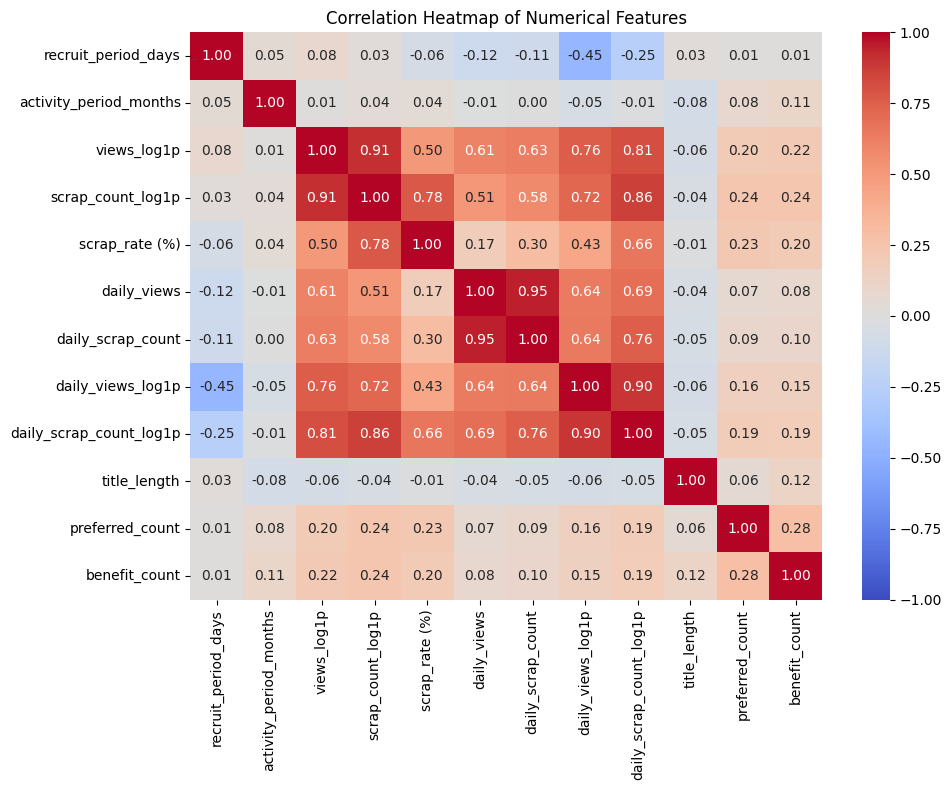

Highly correlated pairs (|r| > 0.7):
scrap_count_log1p - views_log1p: 0.9138
scrap_rate (%) - scrap_count_log1p: 0.7795
daily_scrap_count - daily_views: 0.9480
daily_views_log1p - views_log1p: 0.7610
daily_views_log1p - scrap_count_log1p: 0.7215
daily_scrap_count_log1p - views_log1p: 0.8144
daily_scrap_count_log1p - scrap_count_log1p: 0.8610
daily_scrap_count_log1p - daily_scrap_count: 0.7567
daily_scrap_count_log1p - daily_views_log1p: 0.8980


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/X_model.csv")


num_cols = [
    'recruit_period_days', 'activity_period_months',
    'views_log1p', 'scrap_count_log1p', 'scrap_rate (%)',
    'daily_views', 'daily_scrap_count',
    'daily_views_log1p', 'daily_scrap_count_log1p',
    'title_length', 'preferred_count', 'benefit_count'
]


corr_matrix = df[num_cols].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()


high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly correlated pairs (|r| > 0.7):")
for pair in high_corr:
    print(f"{pair[0]} - {pair[1]}: {pair[2]:.4f}")

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor


df_vif = df.drop(columns=['activity_id'], errors='ignore').copy()


bool_cols = df_vif.select_dtypes(include=['bool']).columns
df_vif[bool_cols] = df_vif[bool_cols].astype(float)


df_vif = df_vif.fillna(df_vif.median())


df_vif = df_vif.astype(float)


vif_data = pd.DataFrame()
vif_data["Feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]


vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data.head(20))

                    Feature         VIF
0               views_log1p  395.036891
1         daily_views_log1p  189.602428
2         scrap_count_log1p   95.448932
3   activity_region_전국/제한없음   54.742076
4   daily_scrap_count_log1p   47.752258
5            scrap_rate (%)   21.775345
6        activity_region_서울   21.388644
7             benefit_count   19.779805
8         daily_scrap_count   17.820042
9               daily_views   15.956854
10             title_length   12.573046
11        recruit_end_month    8.998985
12       activity_region_경기    7.646067
13         title_has_number    4.932990
14      recruit_period_days    4.579606
15      activity_field_서포터즈    4.348317
16       activity_region_부산    4.019469
17          recruit_end_dow    3.497055
18   activity_period_months    3.306378
19       activity_region_경상    2.955342
